In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/world_population.csv")
print(df.head())

   Rank CCA3 Country/Territory           Capital Continent  2022 Population  \
0    36  AFG       Afghanistan             Kabul      Asia         41128771   
1   138  ALB           Albania            Tirana    Europe          2842321   
2    34  DZA           Algeria           Algiers    Africa         44903225   
3   213  ASM    American Samoa         Pago Pago   Oceania            44273   
4   203  AND           Andorra  Andorra la Vella    Europe            79824   

   2020 Population  2015 Population  2010 Population  2000 Population  \
0         38972230         33753499         28189672         19542982   
1          2866849          2882481          2913399          3182021   
2         43451666         39543154         35856344         30774621   
3            46189            51368            54849            58230   
4            77700            71746            71519            66097   

   1990 Population  1980 Population  1970 Population  Area (km²)  \
0         10694796

In [3]:
print(df.info())
print(df.describe())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   Country/Territory            234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    int64  
 12  1970 Population              234 non-null    int64  
 13  Area (km²)          

In [4]:
df = df.dropna()

In [5]:
df.rename(columns={'Country/Territory': 'Country'}, inplace=True)

In [6]:
top10 = df.sort_values(by="2022 Population", ascending=False).head(10)
print(top10[['Country', '2022 Population']])

           Country  2022 Population
41           China       1425887337
92           India       1417173173
221  United States        338289857
93       Indonesia        275501339
156       Pakistan        235824862
149        Nigeria        218541212
27          Brazil        215313498
16      Bangladesh        171186372
171         Russia        144713314
131         Mexico        127504125


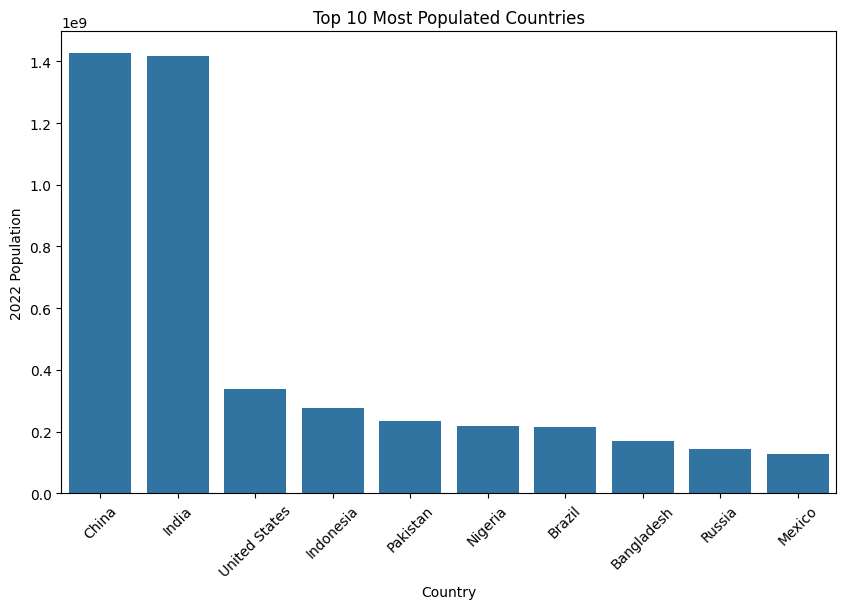

In [7]:
plt.figure(figsize=(10,6))
sns.barplot(x='Country', y='2022 Population', data=top10)
plt.xticks(rotation=45)
plt.title("Top 10 Most Populated Countries")
plt.show()

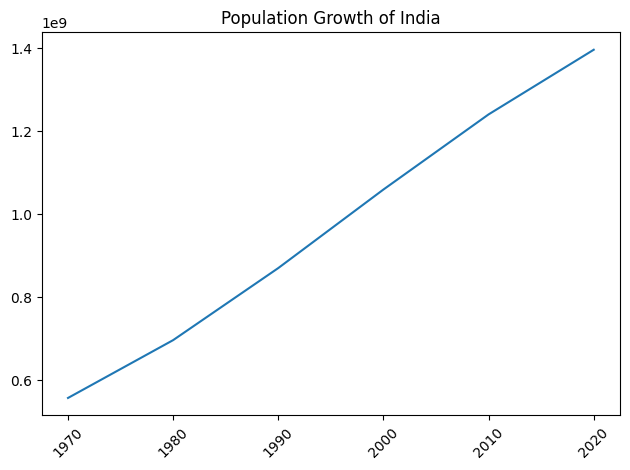

In [16]:
years = ['1970', '1980', '1990', '2000', '2010', '2020']

values = country.iloc[0][[
    '1970 Population','1980 Population','1990 Population',
    '2000 Population','2010 Population','2020 Population'
]]

plt.plot(years, values)
plt.xticks(rotation=45)
plt.title("Population Growth of India")
plt.tight_layout()
plt.show()

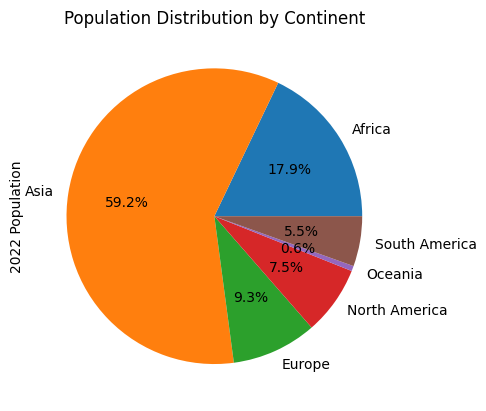

In [11]:
continent_pop = df.groupby('Continent')['2022 Population'].sum()

continent_pop.plot(kind='pie', autopct='%1.1f%%')
plt.title("Population Distribution by Continent")
plt.show()

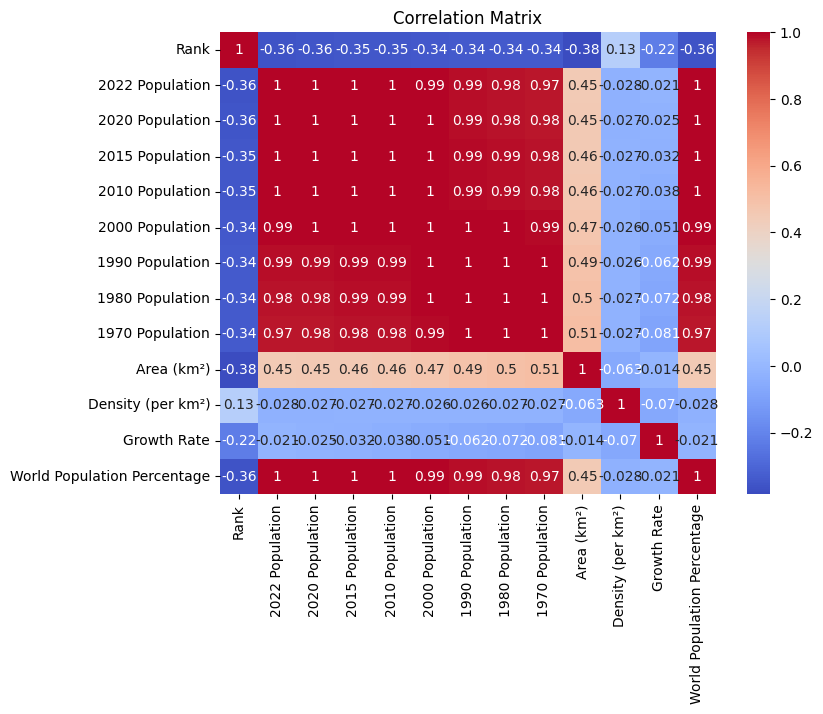

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [14]:
df['Density'] = df['2022 Population'] / df['Area (km²)']

In [15]:
growth = df.sort_values(by='Growth Rate', ascending=False).head(10)
print(growth[['Country', 'Growth Rate']])

      Country  Growth Rate
133   Moldova       1.0691
164    Poland       1.0404
148     Niger       1.0378
202     Syria       1.0376
189  Slovakia       1.0359
55   DR Congo       1.0325
130   Mayotte       1.0319
39       Chad       1.0316
5      Angola       1.0315
124      Mali       1.0314
